## Load necessary modules and set device

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import CSVLogger
from keras.models import *
from unetmodule import get_unet_with_batchnorm, CustomModelCheckpoint
import matplotlib.pyplot as plt
from analysis.analysisutil import *
tf.keras.backend.clear_session()
gpus = tf.config.list_physical_devices('GPU')

## Set up path for data and prediction. 

In [2]:
data_path=f'./data'
prediction_path=f'./results'
os.makedirs(prediction_path, exist_ok=True)

## Inference with pretrained model
### User can use the pretrained model using the cell below, or retrain a model with user's own train, label dataset described later in this notebook

In [ ]:
data_tem=np.load(f'{data_path}/data_tem.npy')
label_tem=np.load(f'{data_path}/label.npy')
pre_model=load_model(f"pretrained/pretrained_cu2o.hdf5",compile=False)
pred_tem=pre_model.predict(data_tem,batch_size=1)
### Convert to binary masks
pred_tem[pred_tem<0.5]=0
pred_tem[pred_tem>=0.5]=1
label_tem[label_tem<0.5]=0
label_tem[label_tem>=0.5]=1

In [6]:
#Example of evaluating true positives, false positives and false negatives for one image
i=0
imagenow=data_tem[i].squeeze()
labnow=label_tem[i].squeeze()
prednow=pred_tem[i].squeeze()
#Get centroid positions of connected components in label and prediction
labposition=centroids(labnow)
predposition=centroids(prednow)
#Compute TP, FP, FN using centroid matching with a radius of 2.5 pixels
TP, FP, FN=match_centroids(labposition, predposition, r=2.5)
print(f'True Positives: {TP}, False Positives: {FP}, False Negatives: {FN}')

True Positives: 563, False Positives: 31, False Negatives: 16


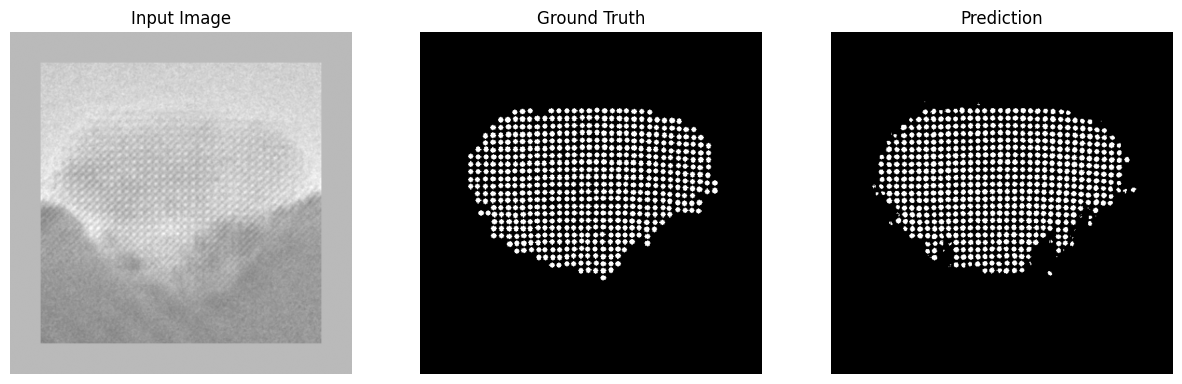

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].set_title('Input Image')
axs[0].imshow(imagenow, cmap='gray', alpha=0.5)
axs[0].axis('off')
axs[1].set_title('Ground Truth')
axs[1].imshow(labnow, cmap='gray')
axs[1].axis('off')
axs[2].set_title('Prediction')
axs[2].imshow(prednow, cmap='gray')
axs[2].axis('off')
plt.show()

## Set up model for training.
### Load dataset named train.npy and label.npy. 
### Model weights are saved every 10 epoch on prediction path

In [ ]:
train_data=np.load(f'{data_path}/data_tem.npy')
label_data=np.load(f'{data_path}/label.npy')
model = get_unet_with_batchnorm()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
save_path = f'{prediction_path}/'+'model_{epoch}.hdf5'
checkpoint_callback = CustomModelCheckpoint(save_path=save_path, save_every=10)
csv_logger = CSVLogger(f'{prediction_path}/log.csv', append=False, separator=',')
model.summary()

## Train the model

In [ ]:
model.fit(train_data, label_data, batch_size=4, epochs=300, verbose=1, callbacks=[checkpoint_callback,csv_logger])